# Connecting to a live API

The other notebooks read a built corpus. This one goes to a **live source**: connect,
see what came back, check it against what you expected, and load it for analysis.

**This is the only notebook that needs the internet.**

---

## The API

**Carbon Intensity API** — `carbonintensity.org.uk`, operated by the National Energy
System Operator with Environmental Defense Fund Europe, the University of Oxford and WWF.

Chosen for four reasons:

- **CC-BY-4.0**, cleared in our licence review with the citation recorded in the c03 catalogue
- **No key, no registration, no account** — nobody is blocked waiting for a credential
- Small, fast responses
- It is the **real version of c03's synthetic `grid_intensity_gco2_per_kwh`**

## Read this before you cache anything

**Reading at source is not redistribution. Saving a copy might be.**

That distinction governs half our catalogue. `metoffice`, `defra`, `deri`, `ahdb` and
`copernicus-sentinel` are all pointer-only: teams may read them, we may not mirror them.

A team that pulls an API into a CSV and commits it has quietly changed what they are
doing from *reading* to *republishing*, and the licence that permitted the first may not
permit the second. CC-BY does permit redistribution with attribution — many licences
do not, and the terms are rarely checked twice.

**So this notebook fetches, analyses in memory, and writes nothing to disk.** If you do
cache during the event, cache outside the repo and check the licence first.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import json
import urllib.request
import urllib.error
from datetime import date, timedelta

import pandas as pd
import matplotlib.pyplot as plt

BASE = 'https://api.carbonintensity.org.uk'

# CC-BY requires attribution wherever the data is used, including in a notebook.
ATTRIBUTION = ('Carbon Intensity data by National Energy System Operator, '
               'licensed under CC BY 4.0. https://carbonintensity.org.uk/')
print(ATTRIBUTION)

Carbon Intensity data by National Energy System Operator, licensed under CC BY 4.0. https://carbonintensity.org.uk/


## Step 1 — one request, and handle it failing

A notebook that assumes the network works is a notebook that dies in a room with bad
wifi. Treat the failure path as part of the code, not an afterthought.

In [2]:
def get(path, timeout=20):
    """GET a JSON endpoint. Returns None on any failure, with a readable reason."""
    url = f'{BASE}{path}'
    req = urllib.request.Request(url, headers={'Accept': 'application/json'})
    try:
        with urllib.request.urlopen(req, timeout=timeout) as r:
            if r.status != 200:
                print(f'HTTP {r.status} from {url}')
                return None
            return json.loads(r.read().decode())
    except urllib.error.HTTPError as e:
        print(f'HTTP {e.code} from {url} — the endpoint exists but refused this request')
    except urllib.error.URLError as e:
        print(f'Could not reach {url}: {e.reason}')
        print('If you are offline, the rest of this notebook will not run. That is expected.')
    except json.JSONDecodeError:
        print(f'{url} did not return JSON — check the path')
    return None

current = get('/intensity')
current

{'data': [{'from': '2026-08-15T17:30Z',
   'to': '2026-08-15T18:00Z',
   'intensity': {'forecast': 168, 'actual': 171, 'index': 'high'}}]}

## Step 2 — look at the shape before you trust it

The single most useful habit with an unfamiliar API. Not the documentation — the
**actual response**, because they disagree more often than anyone admits.

In [3]:
def describe_json(obj, prefix='', depth=0):
    """Walk a JSON object and print its shape: keys, types, example values."""
    pad = '  ' * depth
    if isinstance(obj, dict):
        for k, v in obj.items():
            if isinstance(v, (dict, list)):
                print(f'{pad}{k}: {type(v).__name__}')
                describe_json(v, prefix + k + '.', depth + 1)
            else:
                print(f'{pad}{k}: {type(v).__name__} = {v!r}')
    elif isinstance(obj, list):
        print(f'{pad}[{len(obj)} item(s)]')
        if obj:
            describe_json(obj[0], prefix, depth + 1)

if current:
    describe_json(current)

data: list
  [1 item(s)]
    from: str = '2026-08-15T17:30Z'
    to: str = '2026-08-15T18:00Z'
    intensity: dict
      forecast: int = 168
      actual: int = 171
      index: str = 'high'


## Step 3 — validate against what you expect

An API can change without telling you. Asserting your assumptions here means a later
cell fails with a clear message instead of producing a silently wrong chart.

Note `actual` is **nullable** — it is absent for periods that have not settled yet.
Discovering that in a mean is much worse than discovering it here.

In [4]:
EXPECTED = {'from': str, 'to': str, 'intensity': dict}
EXPECTED_INTENSITY = {'forecast': (int, type(None)),
                      'actual': (int, type(None)),
                      'index': str}

def check_schema(record):
    problems = []
    for key, typ in EXPECTED.items():
        if key not in record:
            problems.append(f'missing key: {key}')
        elif not isinstance(record[key], typ):
            problems.append(f'{key} is {type(record[key]).__name__}, expected {typ.__name__}')
    for key, typ in EXPECTED_INTENSITY.items():
        if key not in record.get('intensity', {}):
            problems.append(f'missing intensity.{key}')
        elif not isinstance(record['intensity'][key], typ):
            problems.append(f'intensity.{key} is {type(record["intensity"][key]).__name__}')
    return problems

if current:
    issues = check_schema(current['data'][0])
    print('schema OK' if not issues else 'SCHEMA PROBLEMS:')
    for i in issues:
        print('  -', i)

schema OK


## Step 4 — fetch a range and load it into pandas

One record is a connectivity test. A range is data. Note the deliberate politeness:
**one request for a whole window**, not 48 requests for half-hours. Rate limits exist,
and a service that is free to you is not free to run.

In [5]:
end = date.today()
start = end - timedelta(days=13)

series = get(f'/intensity/{start.isoformat()}/{end.isoformat()}')

if series:
    df = pd.json_normalize(series['data'])
    df = df.rename(columns={'intensity.forecast': 'forecast',
                            'intensity.actual': 'actual',
                            'intensity.index': 'index_band'})
    df['from'] = pd.to_datetime(df['from'])
    df['to'] = pd.to_datetime(df['to'])
    print(f'{len(df):,} half-hourly periods, {df["from"].min()} to {df["to"].max()}')
    display(df.head())

625 half-hourly periods, 2026-08-01 23:30:00+00:00 to 2026-08-15 00:00:00+00:00


,from,to,forecast,actual,index_band
0,2026-08-01 23:30:00+00:00,2026-08-02 00:00:00+00:00,175,158,moderate
1,2026-08-02 00:00:00+00:00,2026-08-02 00:30:00+00:00,166,156,moderate
2,2026-08-02 00:30:00+00:00,2026-08-02 01:00:00+00:00,168,147,moderate
3,2026-08-02 01:00:00+00:00,2026-08-02 01:30:00+00:00,157,146,moderate
4,2026-08-02 01:30:00+00:00,2026-08-02 02:00:00+00:00,157,149,moderate


## Step 5 — check the data before analysing it

Same discipline as the corpus notebooks. Live data is not cleaner than built data; it
is usually worse, because nobody curated it for you.

In [6]:
if series:
    print('nulls per column:')
    print(df[['forecast','actual','index_band']].isna().sum().to_string())
    print()
    expected_periods = int((df['to'].max() - df['from'].min()).total_seconds() // 1800)
    print(f'periods returned : {len(df):,}')
    print(f'periods expected : {expected_periods:,}  (one per half hour)')
    gaps = expected_periods - len(df)
    print(f'missing periods  : {gaps:,}')
    print()
    print('index_band values:', sorted(df.index_band.dropna().unique()))

nulls per column:
forecast      0
actual        0
index_band    0

periods returned : 625
periods expected : 625  (one per half hour)
missing periods  : 0

index_band values: ['high', 'low', 'moderate', 'very high', 'very low']


## Step 6 — a first look

Forecast against actual, which is the question this API is really about: **how well
does the prediction hold up?**

settled periods      : 625
mean forecast error  : -4.1 gCO2/kWh
mean absolute error  : 12.0 gCO2/kWh
actual range         : 0 to 234 gCO2/kWh


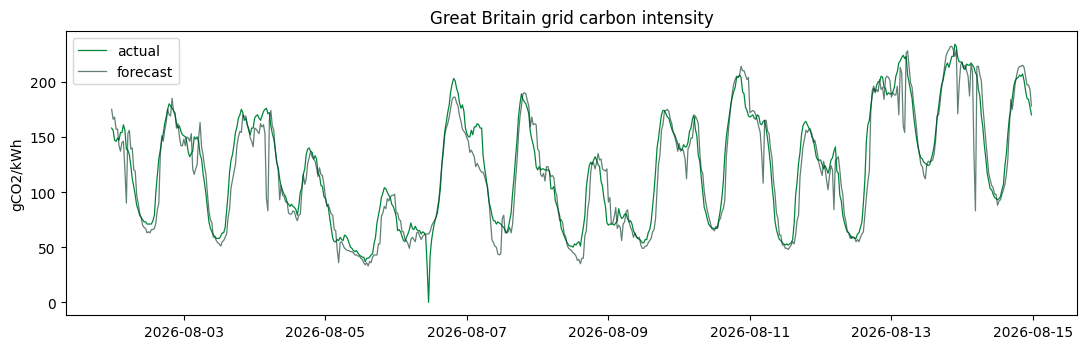

In [7]:
if series and df.actual.notna().any():
    settled = df.dropna(subset=['actual'])
    err = settled.forecast - settled.actual
    print(f'settled periods      : {len(settled):,}')
    print(f'mean forecast error  : {err.mean():+.1f} gCO2/kWh')
    print(f'mean absolute error  : {err.abs().mean():.1f} gCO2/kWh')
    print(f'actual range         : {settled.actual.min()} to {settled.actual.max()} gCO2/kWh')

    fig, ax = plt.subplots(figsize=(11, 3.6))
    ax.plot(settled['from'], settled.actual, lw=0.9, color='#00863a', label='actual')
    ax.plot(settled['from'], settled.forecast, lw=0.9, alpha=0.65, color='#0d3b2c', label='forecast')
    ax.set_ylabel('gCO2/kWh'); ax.legend(); ax.set_title('Great Britain grid carbon intensity')
    plt.tight_layout(); plt.show()

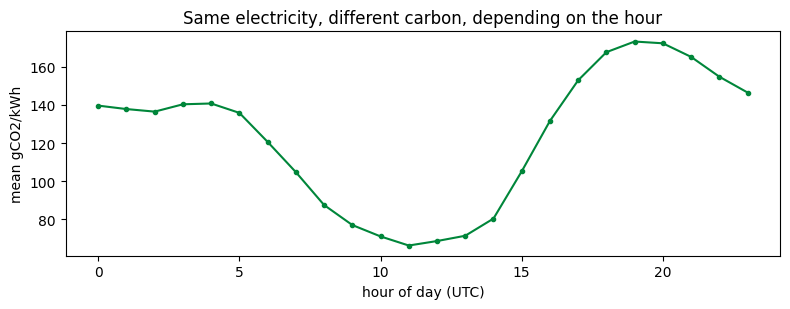

cleanest hour 11:00 at 66, dirtiest 19:00 at 173 gCO2/kWh


In [8]:
if series and df.actual.notna().any():
    # Intensity has a strong daily shape, which is why WHEN a workload runs matters.
    settled = settled.assign(hour=settled['from'].dt.hour)
    by_hour = settled.groupby('hour').actual.mean()
    fig, ax = plt.subplots(figsize=(8, 3.2))
    by_hour.plot(ax=ax, color='#00863a', marker='o', ms=3)
    ax.set_xlabel('hour of day (UTC)'); ax.set_ylabel('mean gCO2/kWh')
    ax.set_title('Same electricity, different carbon, depending on the hour')
    plt.tight_layout(); plt.show()
    print(f'cleanest hour {by_hour.idxmin():02d}:00 at {by_hour.min():.0f}, '
          f'dirtiest {by_hour.idxmax():02d}:00 at {by_hour.max():.0f} gCO2/kWh')

## Connecting this back to c03

c03's `carbon_by_workload` uses a **synthetic** intensity curve, because the real feed
had not been fetched. What you have just pulled is the real thing.

A c03 team could join this to their workload data on timestamp and answer a question
the synthetic corpus cannot support: *what would shifting that batch window actually
save?* That is a genuinely good entry — and it depends on knowing which numbers in your
own dataset are real.

## The rules, restated

1. **Attribute.** CC-BY requires it wherever the data appears — including a slide.
2. **Do not commit fetched data.** Read at source; caching may be republishing.
3. **One request for a range**, not one per row.
4. **Check the licence before reusing any other API.** Ours is in the catalogue: if a
   source says `redistributable: false`, you may read it and we may not mirror it.